# 📘 Домашнє завдання №22. Сучасні архітектури нейромереж

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW22


## Загальні вимоги

* Використовувати Python + PyTorch
* Здати:
  * графіки результатів
  * короткі відповіді на питання після кожного завдання

---

# Завдання 1. Класифікація зображень за допомогою CNN (MNIST)

---

## Опис задачі

Необхідно побудувати CNN, яка класифікує рукописні цифри з датасету MNIST.

Модель повинна визначати:

```
0,1,2,...,9
```

---

## Крок 1. Завантаження даних

Використайте готовий код:

```python
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)
```

---

## Крок 2. Побудуйте CNN

Заповніть пропуски:

```python
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=?,
                out_channels=?,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                ?,
                ?,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                ?,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                10
            )

        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x
```

---

## Крок 3. Навчіть модель

Використайте:

```python
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
```

Навчіть модель:

* 5–10 епох

---

## Крок 4. Обчисліть Accuracy

Напишіть код для оцінки:

```python
correct=0
total=0

with torch.no_grad():

    for images,labels in test_loader:

        outputs=model(images)

        _,predicted=torch.max(
            outputs,
            1
        )

        total+=labels.size(0)

        correct += (
            predicted==labels
        ).sum().item()

print(
    correct/total
)
```

---

## Питання

1. Яку точність отримала модель?
2. Що буде, якщо збільшити кількість Conv шарів?
3. Для чого потрібен MaxPooling?

---


# Завдання 2. Прогнозування часового ряду за допомогою LSTM


## Крок 1. Згенеруйте часовий ряд

Використайте:

```python
import numpy as np
import matplotlib.pyplot as plt

time=np.arange(0,1000)

series = (

    np.sin(
        0.02*time
    )

    +

    0.2*np.random.randn(
        len(time)
    )

)

plt.plot(series)

plt.show()
```

---

## Крок 2. Створіть послідовності

Необхідно:

```
20 попередніх значень

↓

передбачити наступне
```

Використайте:

```python
sequence_length=20

X=[]

y=[]

for i in range(

    len(series)
    -sequence_length

):

    X.append(

        series[
            i:i+sequence_length
        ]

    )

    y.append(

        series[
            i+sequence_length
        ]

    )
```

---

## Крок 3. Перетворіть у Tensor

Заповніть пропуски:

```python
import torch

X=torch.tensor(
    X,
    dtype=torch.float32
)

y=torch.tensor(
    y,
    dtype=torch.float32
)

X = X._______

y = y._______
```

---

## Крок 4. DataLoader

```python
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

dataset=TensorDataset(
    X,
    y
)

loader=DataLoader(

    dataset,

    batch_size=32,

    shuffle=True

)
```

---

## Крок 5. Побудуйте LSTM

Заповніть пропуски:

```python
class LSTMModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(

            input_size=?,

            hidden_size=?,

            batch_first=True

        )

        self.fc = nn.Linear(
            ?,
            1
        )

    def forward(self,x):

        out,(hidden,cell)=self.lstm(x)

        out = out[:,-1,:]

        out=self.fc(out)

        return out
```

---

## Крок 6. Навчіть модель

Використайте:

```python
criterion=nn.MSELoss()

optimizer=torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
```

Навчіть:

* 15–20 епох

---

## Крок 7. Побудуйте графік прогнозів

Приклад:

```python
with torch.no_grad():

    predictions=model(X)

predictions=predictions.numpy()

plt.plot(
    y.numpy(),
    label="True"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.legend()

plt.show()
```

---

## Питання

1. Чи добре модель повторює часовий ряд?
2. Що станеться, якщо збільшити `sequence_length`?

In [1]:
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
#     "pandas",
#     "kagglehub",
#     "kagglesdk",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "kagglehub[pandas-datasets]",
#     "numpy",
#     "matplotlib",
#     "scipy",
#     "statsmodels",
#     "joblib",
#     "torch",
#     "torchvision",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input data
hm_version = 22
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}.git"
# main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone data
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"

# ✅ Рішення: 1. Класифікація зображень за допомогою CNN (MNIST)

- Крок 1. Завантаження даних
- Крок 2. Побудуйте CNN
- Крок 3. Навчіть модель
- Крок 4. Обчисліть Accuracy

Питання

1. Яку точність отримала модель?
2. Що буде, якщо збільшити кількість Conv шарів?
3. Для чого потрібен MaxPooling?

In [3]:
# Downloading data

import torch
import torchvision
import torchvision.transforms as transforms

# Input data

# Solution
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = torchvision.datasets.MNIST(
    root='./resources/data',
    train=True,
    download=True,
    transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./resources/data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# Print result


In [4]:
# Model creating

import numpy as np
import torch.nn as nn

# Input data
rng_seed = 42
image_size = train_dataset[0][0].shape
n_classes = len(train_dataset.classes)

# Solution
torch.manual_seed(rng_seed)


class CNN(nn.Module):
    def __init__(self, data_size, n_groups):
        super(CNN, self).__init__()

        # зберігаємо вхідні дані
        self.n_groups = n_groups
        self.n_channels = data_size[0]
        self.height = data_size[1]
        self.width = data_size[2]
        # визначаємо максимальний розмір
        self.max_size = np.max(data_size)

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=self.n_channels,
                out_channels=self.max_size,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                in_channels=self.max_size,
                out_channels=self.max_size * 2,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # робимо mock для прорахунку розміру
        self.mock_input = torch.zeros(1, self.n_channels, self.height, self.width)
        # оцінюємо результат виконання features
        with torch.no_grad():
            self.mock_output = self.features(self.mock_input)
        # отримуємо кількість усіх елементів
        self.features_size = self.mock_output.numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                self.features_size,
                128
            ),
            nn.ReLU(),
            nn.Linear(
                128,
                self.n_groups
            )
        )

    def forward(self, data):
        data = self.features(data)
        data = self.classifier(data)
        return data


model = CNN(image_size, n_classes)

# Print results
print(model)


CNN(
  (features): Sequential(
    (0): Conv2d(1, 28, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(28, 56, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2744, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [5]:
# Model training

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
from pathlib import Path

# Input data
lr = 0.001
n_epochs = 10
load_model = True
model_file_name = "resources/mnist_cnn_model.pth"

# Solution
file_path = Path(model_file_name)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# try to load model
if load_model and file_path.exists():
    model.load_state_dict(torch.load(model_file_name))
    model.eval()
else:
    total_pbar = tqdm(range(n_epochs), desc="Total training", leave=True)
    for epoch in total_pbar:
        model.train()

        loss_cum = 0.0
        epoch_pbar = tqdm(train_loader, desc=f"Epoch [{epoch + 1}/{n_epochs}] training", leave=True)
        for images, labels in epoch_pbar:
            optimizer.zero_grad()
            predictions = model(images)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()

            current_batch_loss = loss.item()
            loss_cum += loss.item()

        avg_loss = loss_cum / len(train_loader)
        total_pbar.write(f"Epoch: {epoch + 1}, Average Loss: {avg_loss:.4f}, Status: {(epoch + 1.0) / n_epochs:.2%}")
    # save model
    torch.save(model.state_dict(), model_file_name)

# Print results


In [6]:
# Model evaluation

import torch
import apps.reporter as rpt

# Input data

# Solution
# вимикаємо навчання і переходимо в режим тестування
correct = 0
total = 0

model.eval()
with torch.no_grad():
    test_pbar = tqdm(test_loader, desc=f"Testing", leave=True)
    for images, labels in test_pbar:
        predictions = model(images)

        _, predicted = torch.max(predictions, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
rp = rpt.Reporter()
rp.add_item("Accuracy\n(Точність)", rp.format_value(accuracy))

# Print results
rp.print_pd_report("Метрики")

Testing:   0%|          | 0/157 [00:00<?, ?it/s]

Attribute,Result
Accuracy (Точність),0.9911


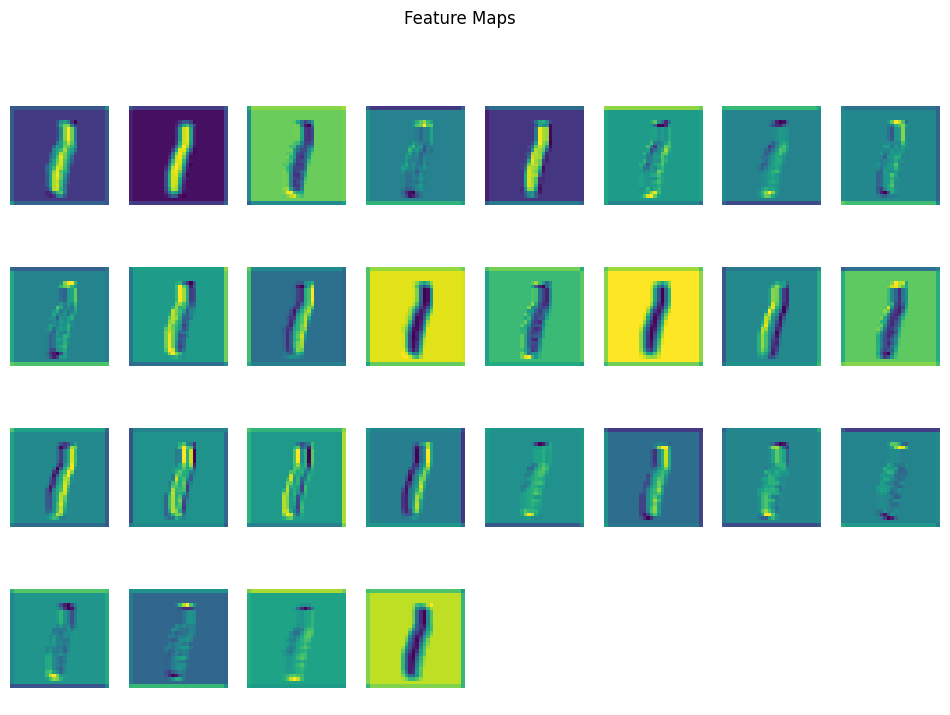

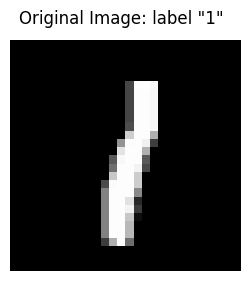

In [7]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
n_cols = 8

# Solution
dataiter = iter(train_loader)
images, labels = next(dataiter)
img = images[0].unsqueeze(0)
label = labels[0]

feature_maps = []


def hook_fn(module, input, output):
    feature_maps.append(output)


# Вішаємо hook на перший conv шар
hook = model.features[0].register_forward_hook(hook_fn)

# вимикаємо навчання і переходимо в режим тестування
model.eval()
with torch.no_grad():
    output = model(img)
hook.remove()

fm = feature_maps[0].squeeze(0)
num_features = fm.shape[0]

n_rows = (num_features + n_cols - 1) // n_cols

img_np = img.squeeze().cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

_, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2 * n_rows))

for i, ax in enumerate(axes.flat):
    if i < num_features:
        ax.imshow(fm[i].cpu().numpy(), cmap='viridis')
    ax.axis('off')

plt.suptitle("Feature Maps")
plt.show()

_, ax = plt.subplots(figsize=(3, 3))
ax.imshow(img_np, cmap='gray')
ax.axis('off')

plt.suptitle(f"Original Image: label \"{label}\"")

plt.show()

Висновок. Модель досягла точності в 0.99, при навчанні протягом 10 епох. При збільшенні шарів будуть виявлятися більш високорівневі деталі та можливе перенавчання, через що збільшиться час навчання. MaxPooling — необхідний для зменшення розмірності карти ознак, та зменшує кількість обчислень для наступних шарів.

# ✅ Рішення: 2. Прогнозування часового ряду за допомогою LSTM


- Крок 1. Згенеруйте часовий ряд
- Крок 2. Створіть послідовності
- Крок 3. Перетворіть у Tensor
- Крок 4. DataLoader
- Крок 5. Побудуйте LSTM
- Крок 6. Навчіть модель
- Крок 7. Побудуйте графік прогнозів

Питання

1. Чи добре модель повторює часовий ряд?
2. Що станеться, якщо збільшити `sequence_length`?

In [19]:
# Data synthesis

import numpy as np
import pandas as pd
from IPython.display import display

# Input data
rng_seed = 42
n = 1000

# Solution
np.random.seed(rng_seed)

time = np.arange(n)
series = np.sin(0.02 * time) + 0.2 * np.random.randn(n)

dates = pd.date_range(start='2015-01-01', periods=n, freq='D')

# створюємо DataFrame
ds_time_series_name = "Часовий ряд для LSTM"
df_time_series = pd.DataFrame({
    'ds': dates,
    'y': series,
})

# Print results
display(df_time_series)

,ds,y
0,2015-01-01,0.099343
1,2015-01-02,-0.007654
2,2015-01-03,0.169527
3,2015-01-04,0.364570
4,2015-01-05,0.033084
...,...,...
995,2017-09-22,0.811424
996,2017-09-23,1.236951
997,2017-09-24,1.015001
998,2017-09-25,0.781660


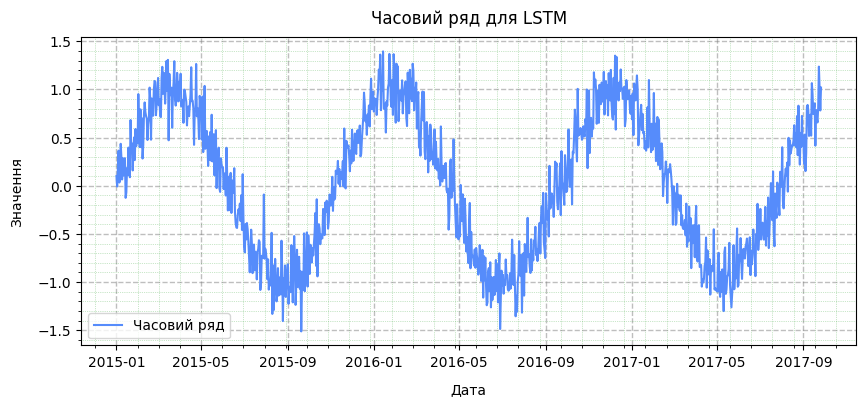

In [20]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = df_time_series

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(data_set["ds"], data_set["y"], label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(ds_time_series_name, pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

In [21]:
# Data preparing

import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

# Input data
sequence_length = 20

# Solution
X_data = []
Y_data = []

for i in range(len(series) - sequence_length):
    X_data.append(series[i:i + sequence_length])
    Y_data.append(series[i + sequence_length])

X_data = torch.tensor(np.asarray(X_data), dtype=torch.float32).unsqueeze(-1)
Y_data = torch.tensor(np.asarray(Y_data), dtype=torch.float32).unsqueeze(-1)

dataset = TensorDataset(X_data, Y_data)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Print results

In [22]:
# Model creating

import numpy as np
import torch.nn as nn

# Input data
rng_seed = 42
image_size = train_dataset[0][0].shape
n_classes = len(train_dataset.classes)

# Solution
torch.manual_seed(rng_seed)


class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, data):
        out, (hidden, cell) = self.lstm(data)
        out = out[:, -1, :]
        out = self.fc(out)
        return out


model = LSTMModel()

# Print results
print(model)


LSTMModel(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [24]:
# Model training

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
from pathlib import Path

# Input data
lr = 0.001
n_epochs = 20
load_model = True
model_file_name = "resources/lstm_model.pth"

# Solution
file_path = Path(model_file_name)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# try to load model
if load_model and file_path.exists():
    model.load_state_dict(torch.load(model_file_name))
    model.eval()
else:
    total_pbar = tqdm(range(n_epochs), desc="Total training", leave=True)
    for epoch in total_pbar:
        model.train()

        loss_cum = 0.0
        epoch_pbar = tqdm(loader, desc=f"Epoch [{epoch + 1}/{n_epochs}] training", leave=True)
        for batch_x, batch_y in epoch_pbar:
            optimizer.zero_grad()

            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()

            current_batch_loss = loss.item()
            loss_cum += loss.item()

        avg_loss = loss_cum / len(train_loader)
        total_pbar.write(f"Epoch: {epoch + 1}, Average Loss: {avg_loss:.4f}, Status: {(epoch + 1.0) / n_epochs:.2%}")
    # save model
    torch.save(model.state_dict(), model_file_name)

# Print results
